# Attempting to Model NGC6569 with PyfalcON


In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 200  # Set to 100MB or whatever you need

from IPython.display import HTML

import pandas as pd

import pyfalcon

In [ ]:
import astropy.coordinates as coord
import astropy.units as u
from astropy.constants import G
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms

import agama

import importlib
import sys
from pathlib import Path

from time import time

START_DIR = Path.cwd().resolve()
SEARCH_DIRS = (START_DIR, *START_DIR.parents)
NGC6569_DIR = next(
    (path for path in SEARCH_DIRS if (path / "milkyway").is_dir() and (path / "helpers").is_dir()),
    None,
)
if NGC6569_DIR is None:
    NGC6569_DIR = next(
        (path / "joe's_Code" / "ngc6569" for path in SEARCH_DIRS
         if (path / "joe's_Code" / "ngc6569" / "milkyway").is_dir()),
        None,
    )
if NGC6569_DIR is None:
    raise FileNotFoundError("Could not locate joe's_Code/ngc6569 from the current working directory")

DATA_DIR = NGC6569_DIR / "data"
OUTPUT_DIR = NGC6569_DIR / "output"
MILKYWAY_DIR = NGC6569_DIR / "milkyway"
FIGURE_DIR = OUTPUT_DIR / "figures"
ORBIT_FIGURE_DIR = FIGURE_DIR / "orbits"
MASS_LOSS_FIGURE_DIR = FIGURE_DIR / "mass_loss"
OBSERVABLE_FIGURE_DIR = FIGURE_DIR / "observables"
TIDAL_TAIL_FIGURE_DIR = FIGURE_DIR / "tidal_tail"
for _path in (DATA_DIR, OUTPUT_DIR, ORBIT_FIGURE_DIR, MASS_LOSS_FIGURE_DIR, OBSERVABLE_FIGURE_DIR, TIDAL_TAIL_FIGURE_DIR):
    _path.mkdir(parents=True, exist_ok=True)
if str(NGC6569_DIR) not in sys.path:
    sys.path.insert(0, str(NGC6569_DIR))

import helpers.leap_frog as leap_frog
importlib.reload(leap_frog)
from helpers.leap_frog import kdk_leapfrog_TD, kdk_leapfrog, kdk_leapfrog_cached

#from leap_frog_hdf5 import kdk_leapfrog_hdf5, load_simulation_hdf5

In [3]:
# default Astropy Galactocentric frame parameters to the values adopted in Astropy v4.0:
_ = coord.galactocentric_frame_defaults.set('v4.0')

# set Agama units 
# working units: 1 Msun, 1 kpc, 1 km/s
agama.setUnits(length=1*u.kpc, velocity=1*u.km/u.s, mass=1*u.Msun)
print("Newton G in Agama units,",agama.G)

# Check the current unit system
print("Current Agama units:")
print(f"Length unit: {agama.getUnits()['length']}")
print(f"Velocity unit: {agama.getUnits()['velocity']}")  
print(f"Time unit: {agama.getUnits()['time']}")
print(f"Mass unit: {agama.getUnits()['mass']}")

agama_time_unit = agama.getUnits()["time"]
print(agama_time_unit)

Newton G in Agama units, 4.30091727067736e-06
Current Agama units:
Length unit: 1.0 kpc
Velocity unit: 1.0 km / s
Time unit: 977.792221683525 Myr
Mass unit: 1.0 solMass
977.792221683525 Myr


In [4]:
# Use the Hunter rotating potential 
pot_ext = agama.Potential(str(MILKYWAY_DIR / "MWPotentialHunter24_full.ini")) 
pot_rot = agama.Potential(str(MILKYWAY_DIR / "MWPotentialHunter24_rotating.ini")) 
pot_bovy = agama.Potential(str(MILKYWAY_DIR / "MWPotential2014.ini")) 

pot_use = pot_rot

In [5]:
pot_ext

CompositePotential{ Multipole, CylSpline } (symmetry: Triaxial)

In [6]:
# NG6569 coordinates 

c = coord.SkyCoord(ra = 273.412*u.degree, dec = -31.827*u.degree,
                        distance=(10.5)*u.kpc,
                        pm_ra_cosdec= -4.125*u.mas/u.yr,
                        pm_dec= -7.354*u.mas/u.yr,
                        radial_velocity= -49.82*u.km/u.s)

# transform to galactic centeric 
c_gc = c.transform_to(coord.Galactocentric).data
print(c_gc._differentials)

{'s': <CartesianDifferential (d_x, d_y, d_z) in kpc mas / (rad yr)
    (-6.71192364, -36.78139749, 5.0482508)>}


In [7]:
# creat phase space object
w0 = gd.PhaseSpacePosition(c_gc)
print("initial position :", w0.pos)
print("initial velocity :", w0.vel)
print("Need to convert velocity to km/s")

pos_0 = np.r_[w0.pos.x.value, w0.pos.y.value, w0.pos.z.value]
vel_0 = np.r_[w0.vel.d_x.to(u.km/u.s).value, 
              w0.vel.d_y.to(u.km/u.s).value,
              w0.vel.d_z.to(u.km/u.s).value]
print("position", pos_0) 
print("velocity", vel_0) 

initial position : (2.30319138, 0.08753024, -1.22751023) kpc
initial velocity : (-6.71192364, -36.78139749, 5.0482508) kpc mas / (rad yr)
Need to convert velocity to km/s
position [ 2.30319138  0.08753024 -1.22751023]
velocity [ -31.81767579 -174.36112841   23.93108381]


In [8]:
# check against 
# -31.81767578935911 km / s -174.361128405216 km / s 23.931083813686854 km / s

In [10]:
# integrate orbit 
tfin= -200*u.Myr
nt=2000
t_eval = np.linspace(0, tfin, nt)
t_scipy = t_eval.to(u.Gyr).value/agama_time_unit.to(u.Gyr).value
t_scipy

array([ 0.00000000e+00, -1.02322378e-04, -2.04644755e-04, ...,
       -2.04337788e-01, -2.04440111e-01, -2.04542433e-01], shape=(2000,))

In [11]:
def rhs(t,state): 
    
    pos = state[:3]
    vel = state[3:]

    acc = pot_use.force(pos, t=t)
    return np.r_[vel, acc] 

# integrate with solve_ivp
from scipy.integrate import solve_ivp

state_0 = np.r_[pos_0, vel_0] 
print(state_0, state_0.shape)

t_span = (0, t_scipy[-1]) 
sol = solve_ivp(rhs, t_span, state_0, t_eval =t_scipy, rtol=1e-10, atol=1e-10)
orbit = sol["y"]

[ 2.30319138e+00  8.75302429e-02 -1.22751023e+00 -3.18176758e+01
 -1.74361128e+02  2.39310838e+01] (6,)


In [12]:
x = orbit[0,:]
y = orbit[1,:]
z = orbit[2,:]
vx = orbit[3,:]
vy = orbit[4,:]
vz = orbit[5,:]

In [13]:
# Agama orbit
# Calculate orbit
orbit = agama.orbit(potential=pot_use, 
                   ic=state_0, 
                   time=t_span[1],      # Total integration time
                   trajsize=nt)   # Number of output points

In [14]:
orbit[1].shape

(2000, 6)

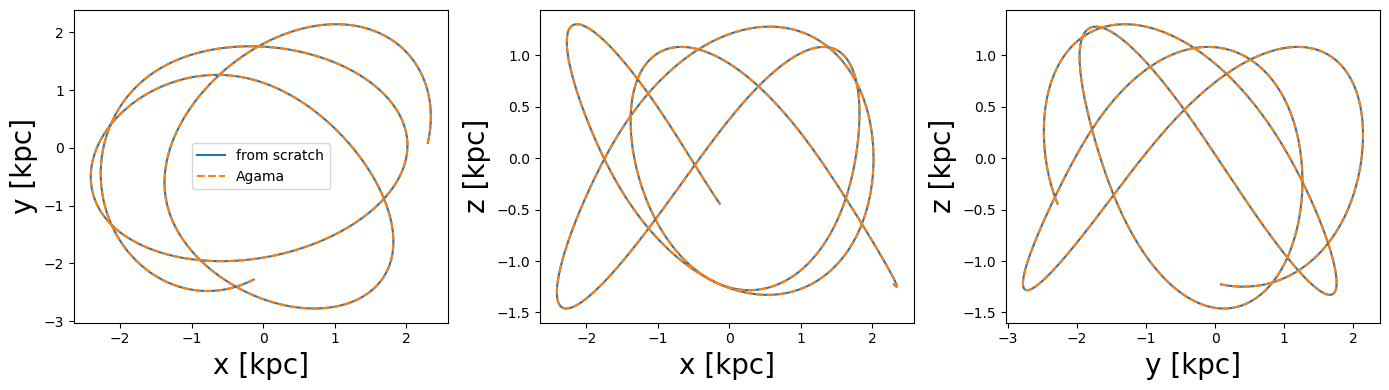

In [15]:
# 2-D orbit figures 
fig = plt.figure(figsize=(14, 4))

ax = fig.add_subplot(131)
ax.set_xlabel("x [kpc]", size=20) 
ax.set_ylabel("y [kpc]", size=20)
ax.plot(x,y, label="from scratch")
ax.plot(orbit[1][:,0], orbit[1][:,1], "--", label="Agama") 
ax.legend()

ax = fig.add_subplot(132)
ax.set_xlabel("x [kpc]", size=20) 
ax.set_ylabel("z [kpc]", size=20)
ax.plot(x,z)
ax.plot(orbit[1][:,0], orbit[1][:,2], "--") 

ax = fig.add_subplot(133)
ax.set_xlabel("y [kpc]", size=20) 
ax.set_ylabel("z [kpc]", size=20)
ax.plot(y,z)
ax.plot(orbit[1][:,1], orbit[1][:,2], "--") 
plt.tight_layout()
fig.savefig(ORBIT_FIGURE_DIR / "ngc6569_oribit.pdf")

## GyrfalcON manuals
* https://teuben.github.io/nemo/man_html/gyrfalcON.1.html
* 



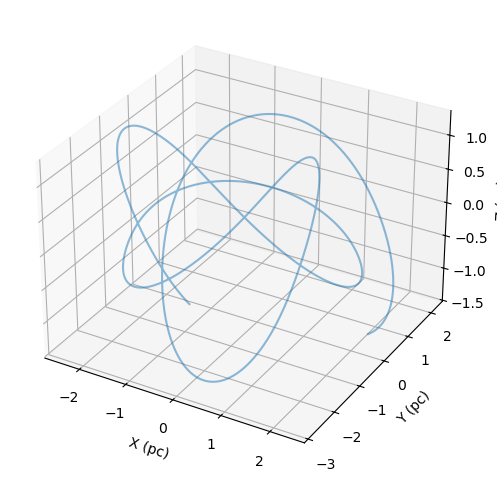

In [16]:
# Create figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
    
# Create scatter plot with color mapping by radius
ax.plot(x,y,z, alpha = .5) 
ax.set_xlabel('X (pc)')
ax.set_ylabel('Y (pc)')
ax.set_zlabel('Z (pc)')
fig.savefig(ORBIT_FIGURE_DIR / "ngc6569_3d_orbit.pdf") 


In [18]:
# Define the parameters for your King model
W0_value = 7.0  # Example W0 value
# create an isolated star cluster
r_scale = 1/1000
m = 2.3*1e5*(2)
pot_sat = agama.Potential(type='king', W0=W0_value, scaleRadius=r_scale, mass=m)
df_sat = agama.DistributionFunction(type='quasispherical', potential=pot_sat)
Nbody = 150000
xv, mass = agama.GalaxyModel(pot_sat, df_sat).sample(Nbody)

r_agama = np.sqrt(xv[:,0]**2 + xv[:,1]**2 + xv[:,2]**2) 
v_agama = np.sqrt(xv[:,3]**2 + xv[:,4]**2 + xv[:,5]**2) 

print("Agama G:", agama.G)

cluster_data = np.c_[mass, xv]
cluster_data.shape
np.savetxt(DATA_DIR / "cluster_data.txt", cluster_data)

Agama G: 4.30091727067736e-06


Text(0.5, 0, 'Z [kpc]')

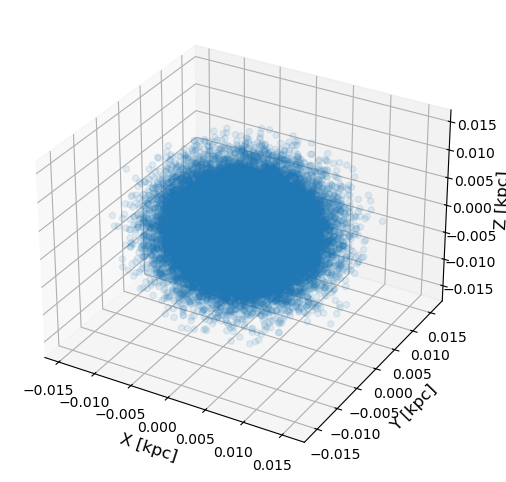

In [285]:

# look at positions in 3D
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
    
# Create scatter plot
ax.scatter(xv[:,0], xv[:,1], xv[:,2], alpha=0.1, s=20)
    
# Labels and title
ax.set_xlabel('X [kpc]', fontsize=12)
ax.set_ylabel('Y [kpc]', fontsize=12)
ax.set_zlabel('Z [kpc]', fontsize=12)
    

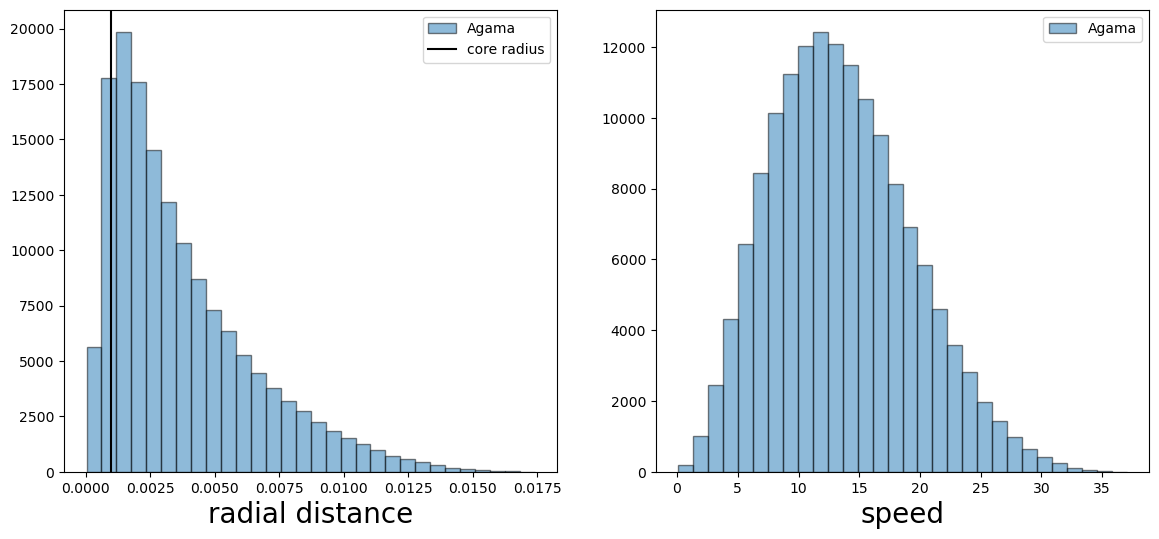

In [286]:
fig = plt.figure(figsize=(14,6))

ax=fig.add_subplot(121)
ax.set_xlabel("radial distance", size=20) 
ax.hist(r_agama, bins=30, edgecolor="black", alpha=.5, label ="Agama")

ax.axvline(r_scale, color="black", label="core radius")
ax.legend(loc=0) 

ax=fig.add_subplot(122)
ax.set_xlabel("speed", size=20) 
ax.hist(v_agama, bins=30, edgecolor="black", alpha=.5, label ="Agama")

ax.legend(loc=0) 


In [287]:
pos_0 = np.r_[x[-1], y[-1], z[-1]]
vel_0 = np.r_[vx[-1], vy[-1], z[-1]]
print(pos_0)
print(vel_0) 

[-0.13356328 -2.27827074 -0.44259326]
[-129.16134153  -82.14009399   -0.44259326]


In [288]:
print("make this a function")

def shift_to_gc(xv, pos_0, vel_0): 

    x = xv[:,0] + pos_0[0]
    y = xv[:,1] + pos_0[1]
    z = xv[:,2] + pos_0[2]

    vx = xv[:,3] + vel_0[0]
    vy = xv[:,4] + vel_0[1]
    vz = xv[:,5] + vel_0[2]


    print("checks")
    print(np.mean(x), np.mean(y), np.mean(z))
    print(pos_0)


    print(np.mean(vx), np.mean(vy), np.mean(vz))
    print(vel_0)

    return np.column_stack((x, y, z)), np.column_stack((vx, vy, vz))


make this a function


In [289]:
# pos_0 = np.column_stack((x, y, z))
# vel_0 = np.column_stack((vx, vy, vz))
# vel_0.shape

pos_0 , vel_0 = shift_to_gc(xv, pos_0, vel_0)

checks
-0.13355979463122905 -2.27827702596787 -0.4425933187302422
[-0.13356328 -2.27827074 -0.44259326]
-129.14879461766608 -82.12625463687772 -0.4449089584146095
[-129.16134153  -82.14009399   -0.44259326]


In [290]:
np.sum(mass/1e5)
np.savetxt(DATA_DIR / "ngc6569_mass.txt", mass)

In [291]:
time_unit=u.kpc.to(u.km)*u.s.to(u.Gyr)
time_unit

0.9777922216807892

In [292]:
tmax = -tfin.to(u.Gyr).value/time_unit
print("maximum time", tmax)
print(t_scipy[-1])

maximum time 0.204542433009139
-0.2045424330085667


In [293]:
kmax=16
tau = 2**(-kmax)*time_unit
print("time step:", tau) 
nt=int(tmax/tau) + 1
print("number of time steps:", nt)

eps = 1/1000  # II 
eps = .1/1000 # I 
eps_power = -4
eps = (2**eps_power)/1000
print("softening length:", eps) 

time step: 1.4919925257580401e-05
number of time steps: 13710
softening length: 6.25e-05


In [294]:
(nt)*tau

0.2045521752814273

In [295]:
print(nt)

13710


In [296]:
downsample=20
#filename="ngc_6569_runI"
#nt=1000

In [297]:
pot_use

Rotating CompositePotential{ Multipole, CylSpline } (symmetry: Bisymmetric)

In [ ]:
# Set up caching for KDK simulations
KDK_CACHE_DIR = OUTPUT_DIR / "kdk_cache"
KDK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Get potential path for cache invalidation
pot_rot_path = MILKYWAY_DIR / "MWPotentialHunter24_rotating.ini"

# Run cached KDK simulation
t1 = time()
sim_data_reader, cache_path, cache_hit = kdk_leapfrog_cached(
    pot_use, pos_0, vel_0, mass, nt, tau, agama.G, eps,
    time_unit, downsample, KDK_CACHE_DIR, 
    pot_path=pot_rot_path,
    use_cache=True,
    last_snapshot=False
)
t2 = time()

# Convert reader to list for compatibility with rest of notebook
sim_data = list(sim_data_reader)

print(f"Cache hit: {cache_hit}")
print(f"Cache path: {cache_path}")
print(f"run time: {t2-t1} seconds ({(t2-t1)/60} minutes)")

In [300]:
len(sim_data)

686

In [303]:
# get time array 
time_array=[]
for i in range(len(sim_data)): 

    t = sim_data[i]["time"]
    time_array.append(t*1000) 

time_array=np.array(time_array)    

In [304]:
from helpers.bound_funcs import get_bound_particles

bound_data = get_bound_particles(sim_data, mass)

In [ ]:
# Create figure
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)  # Fixed: added subplot number
ax.set_aspect('equal')     # Fixed: proper way to set equal aspect
ax.set_xlabel('X (kpc)')
ax.set_ylabel('Y (kpc)')
L = 4
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)

ax.plot(orbit[1][:,0],orbit[1][:,1], color="black", alpha=.1, label="Agama")
# gala orbit 
#ax.plot(orbit.pos.x,orbit.pos.y, color="black", alpha=.5, label="Gala")
pts, = ax.plot([], [], "o", color="blue", alpha=0.25, markersize=1)  # Added markersize for visibility
plt.close()

# Initialization function
def init():
    pts.set_data([], []) 
    return pts, 

def draw(i):  # Fixed: use 'i' instead of undefined 'nt'

    data = sim_data[i]
    pos = data["pos"]


    x = pos[:,0]
    y = pos[:,1]
    z = pos[:,2] 
    
    pts.set_data(x, y)  # Fixed: missing closing bracket and proper syntax

    time = np.round(time_array[i] + tfin.value,0) 
    
    ax.set_title(f'NGC6569 5 (X-Y Plane) - Time: {time} Myr')  # Fixed: use 'i' instead of 'nt'
    return pts, 
    
anim = FuncAnimation(fig, draw, init_func=init, frames=len(sim_data), interval=50, blit=True)
anim.save(str(OUTPUT_DIR / "6569_2d_II.gif")) 
HTML(anim.to_jshtml())

In [306]:
len(sim_data)

686

In [307]:
def trajectories(bound_data, sim_data): 
    """
    Extract time evolution trajectories of bound cluster properties from simulation data.
    
    This function processes the output from bound particle tracking to create clean
    time series arrays for analysis and plotting of cluster evolution.
    
    Parameters:
    -----------
    bound_data : list of dict
        List of dictionaries containing bound particle data at each timestep.
        Each dictionary should contain keys: 'total mass', 'total energy', 'pos', 'vel'
    sim_data : list of dict
        List of dictionaries containing simulation data at each timestep.
        Each dictionary should contain key: 'time'
        
    Returns:
    --------
    dict : Dictionary containing trajectory arrays
        'mass' : array, shape (n,) - Total mass of bound particles vs time
        'energy' : array, shape (n,) - Total energy of bound particles vs time  
        'time' : array, shape (n,) - Time array
        'pos' : array, shape (n, 3) - Center of mass position vs time
        'vel' : array, shape (n, 3) - Center of mass velocity vs time

    """
    
    n = len(bound_data)
    
    # Validate input lengths match
    if len(sim_data) != n:
        raise ValueError(f"Length mismatch: bound_data has {n} entries, sim_data has {len(sim_data)}")
    
    # Initialize trajectory arrays
    time_array = np.zeros(n)
    mass_traj = np.zeros(n)
    energy_traj = np.zeros(n)
    r_traj = np.zeros((n, 3))
    d_traj = np.zeros(n)
    v_traj = np.zeros((n, 3))
    
    # Extract data for each timestep
    for i in range(n): 
        # Extract bound particle properties
        mass_traj[i] = bound_data[i]["total mass"]
        energy_traj[i] = bound_data[i]["total energy"]
        r_traj[i, :] = bound_data[i]["pos"]
        v_traj[i, :] = bound_data[i]["vel"]
        d_traj[i] = np.linalg.norm(r_traj[i,:]) 
        
        # Extract time from simulation data
        time_array[i] = sim_data[i]["time"] 
    
    # Package results into dictionary
    traj = {
        'mass': mass_traj,
        'energy': energy_traj,
        'time': time_array,
        'pos': r_traj,
        'vel': v_traj,
        'distance': d_traj
    }
    
    return traj

traj = trajectories(bound_data, sim_data)

In [309]:
def cluster_frame(r_cm, v_cm, pos, vel): 
    """
    Compute unit vectors for cluster frame and transform positions to that frame.
    
    Parameters:
    -----------
    r_cm : array, shape (3,)
        Position vector from galactic center to cluster center of mass
    v_cm : array, shape (3,)
        Velocity vector of cluster center of mass  
    pos : array, shape (N, 3)
        Positions of N particles
    vel : array, shape (N, 3)
        Velocities of N particles
        
    Returns:
    --------
    tuple : (x_hat, y_hat, z_hat, pos_cluster_frame, vel_cluster_frame, omega_vec)
        x_hat, y_hat, z_hat : unit vectors in cluster frame
        pos_cluster_frame : array, shape (N, 3) - positions in cluster frame
        vel_cluster_frame : array, shape (N, 3) - velocities in cluster frame
        omega_vec : array, shape (3,) - angular velocity vector of cluster
    """
    
    # x-unit vector points toward galactic center 
    x_hat = -r_cm / np.linalg.norm(r_cm)
    
    # z-unit vector is perpendicular to orbital plane (r × v direction)
    L_vec = np.cross(r_cm, v_cm)
    z_hat = L_vec / np.linalg.norm(L_vec)
    
    # y-unit vector completes right-handed system (z × x)
    y_hat = np.cross(z_hat, x_hat)
    
    # Angular velocity vector: ω = L / |r|²
    r_cm_mag_sq = np.dot(r_cm, r_cm)
    omega_vec = L_vec / r_cm_mag_sq
    
    # Transform positions to cluster frame
    # Each row of pos gets dotted with each unit vector
    x_coords = np.dot(pos, x_hat)  # shape (N,)
    y_coords = np.dot(pos, y_hat)  # shape (N,)
    z_coords = np.dot(pos, z_hat)  # shape (N,)
    
    # Stack coordinates to form (N, 3) array
    pos_cluster_frame = np.column_stack([x_coords, y_coords, z_coords])
    
    # Transform velocities to cluster frame
    # Each row of vel gets dotted with each unit vector
    vx_coords = np.dot(vel, x_hat)  # shape (N,)
    vy_coords = np.dot(vel, y_hat)  # shape (N,)
    vz_coords = np.dot(vel, z_hat)  # shape (N,)
    
    # Stack velocity components to form (N, 3) array
    vel_cluster_frame = np.column_stack([vx_coords, vy_coords, vz_coords])
    
    return x_hat, y_hat, z_hat, pos_cluster_frame, vel_cluster_frame, omega_vec
        
  

In [310]:
def get_cluster_data(bound_data, sim_data): 
    n=len(bound_data) 

    cluster_data = []

    # angular velocity of cluster
    omega_c = np.zeros((n, 3))

    # unit vectors in cluster frame 
    for i in range(n): 

        b_data = bound_data[i]
        r_cm = b_data["pos"]
        v_cm = b_data["vel"]

        pos = sim_data[i]["pos"]
        vel = sim_data[i]["vel"]

        obj = cluster_frame(r_cm, v_cm, pos, vel)

        x_hat, y_hat, z_hat, pos_cluster_frame, vel_cluster_frame, omega_vec = obj
        
        c_data={}
        
        c_data["omega"] = omega_vec
        c_data["x_hat"] = x_hat
        c_data["y_hat"] = y_hat
        c_data["z_hat"] = z_hat 
        c_data["pos"]= pos_cluster_frame
        c_data["vel"]=vel_cluster_frame

        cluster_data.append(c_data)
 
    return cluster_data

cluster_data= get_cluster_data(bound_data, sim_data) 

In [311]:
def get_tidal_data(traj, pot_ext): 

    pos = traj["pos"]
    n=pos.shape[0]

    tidal = np.zeros((n,3))
    max_tidal = np.zeros(n)

    for i in range(n): 

        H = np.zeros((3, 3))
        
        hess = pot_ext.eval(pos[i,:], der=True)
    
    
        # Upper triangular indices
        triu_indices = np.triu_indices(3)
        H[triu_indices] = hess
    
        # Make symmetric
        H = H + H.T - np.diag(np.diag(H))

        tidal[i,:] = np.linalg.eigvals(H)

        max_tidal[i] = np.max(tidal[i,:]) 

    return tidal, max_tidal 

tidal, max_tidal = get_tidal_data(traj, pot_ext)

In [313]:
gc_energy = np.zeros(len(bound_data))

i=0
for bdata in bound_data: 

    e = bdata["total energy"]
    gc_energy[i] = e
    i+=1

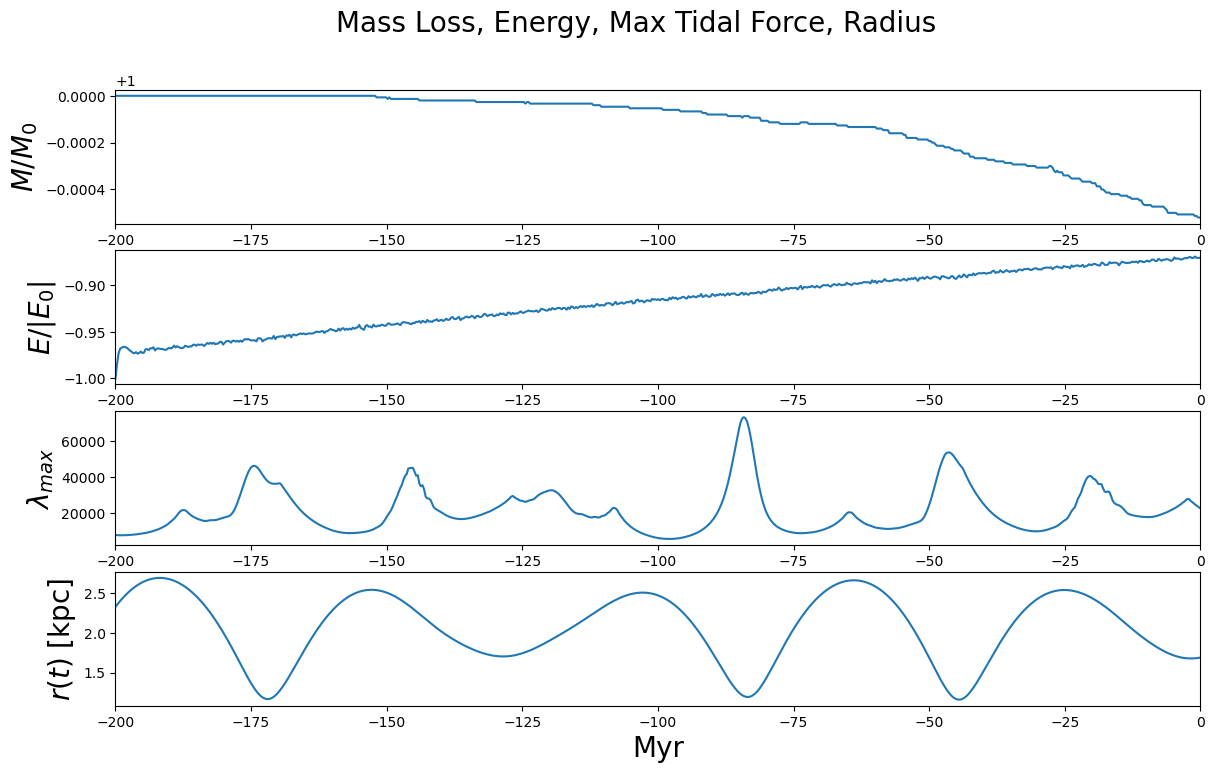

In [315]:

max_t=np.max(max_tidal)

fig = plt.figure(figsize=(14, 8 ))
fig.suptitle('Mass Loss, Energy, Max Tidal Force, Radius ', size=20)
ax = fig.add_subplot(411)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$M/M_0$", size=20) 
#ax.set_xlabel("Myr", size=20)

M0=traj["mass"][0]
ax.plot(time_array+tfin.value, traj["mass"]/M0)


ax = fig.add_subplot(412)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$E/|E_0|$", size=20) 
#ax.set_xlabel("Myr", size=20) 
E = traj["energy"]
ax.plot(time_array+tfin.value, E/np.abs(E[0])) 


ax = fig.add_subplot(413)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$\lambda_{max}$ ", size=20) 
ax.set_xlabel("Myr", size=20) 
ax.plot(time_array + tfin.value, max_tidal)


ax = fig.add_subplot(414)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$r(t)$ [kpc]", size=20) 
ax.set_xlabel("Myr", size=20) 
ax.plot(time_array + tfin.value, traj["distance"])

fig.savefig(MASS_LOSS_FIGURE_DIR / "6569_ml_II.pdf") 

# print("Maybe add distance from galactic center." ) 
# print("How does tidal stripping compare at large tidal tensor versus Particle Spray method.") 
# print("why is there a dip in energy right before an increase?" ) 


In [ ]:
# Create figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)  # Fixed: added subplot number
ax.set_aspect('equal')     # Fixed: proper way to set equal aspect
ax.set_xlabel('X [kpc]', size=20)
ax.set_ylabel('Y [kpc]', size=20)
L = .3
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)

pts, = ax.plot([], [], "o", color="blue", alpha=0.1, markersize=1)  # Added markersize for visibility
# free, = ax.plot([], [], "o", color = "red", alpha = .3, markersize=1, label="stripped") 
# circ, = ax.plot([], [], color = "orange", alpha =.5 ,label = "Jacobi radius") 
# circ2, = ax.plot([], [], color = "black", alpha=.5, label = "energy based bound radius") 
# ax.legend(loc=2, fontsize="large") 
plt.close()

theta = np.linspace(0,2*np.pi,1000) 

# Initialization function
def init():
    pts.set_data([], []) 
    # circ.set_data([], []) 
    # circ2.set_data([], []) 
    # free.set_data([], []) 
    return pts, #circ, circ2, free,  

def draw(i):  # Fixed: use 'i' instead of undefined 'nt'

    data = cluster_data[i]
    pos = data["pos"]

    x = pos[:,0] - np.mean(pos[:,0]) 
    y = pos[:,1] - np.mean(pos[:,1]) 
    #z = pos[:,2] - np.mean(pos[:,2]) 
    
    pts.set_data(x, y)  # Fixed: missing closing bracket and proper syntax

    # free_x = x[free_mask]
    # free_y = y[free_mask] 

    # free.set_data(free_x, free_y) 

    # x = r_tidal[i]*np.cos(theta)
    # y = r_tidal[i]*np.sin(theta) 

    # circ.set_data(x, y)

    # r_bound = bound_data[i]["r_bound"]
    
    # x = r_bound*np.cos(theta)
    # y = r_bound*np.sin(theta)

    # circ2.set_data(x, y)

    time = np.round(time_array[i] + tfin.value,0) 
    
    ax.set_title(f'Palomar 5 (X-Y Plane) - Time: {time} Myr')
    
    return pts, #circ, circ2,free, 
    
anim = FuncAnimation(fig, draw, init_func=init, frames=len(sim_data), interval=100, blit=True)
#anim.save("pal5test_blob_rj.mp4") 
HTML(anim.to_jshtml())

In [ ]:
len(cluster_data)

## Compare mass loss across the three Milky Way potentials


In [ ]:
from helpers.leap_frog import kdk_leapfrog_to_disk
from helpers.snapshot_store import SnapshotBinaryReader


In [ ]:
# Cache each potential's full main KDK simulation
# Snapshots stream straight to a binary file as they're produced (kdk_leapfrog_to_disk /
# helpers/snapshot_store.py), so a run never needs to hold all snapshots in memory at once,
# and any snapshots already flushed survive a kernel crash instead of being lost.
import hashlib
import json

USE_MAIN_KDK_CACHE = True
MAIN_KDK_CACHE_DIR = OUTPUT_DIR / "main_kdk_cache"
MAIN_KDK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def main_potential_path(potential):
    """Return the source .ini file for one of this notebook's three potentials."""
    candidates = [
        (pot_ext, MILKYWAY_DIR / "MWPotentialHunter24_full.ini"),
        (pot_rot, MILKYWAY_DIR / "MWPotentialHunter24_rotating.ini"),
        (pot_bovy, MILKYWAY_DIR / "MWPotential2014.ini"),
    ]
    for candidate, path in candidates:
        if potential is candidate:
            return path
    raise ValueError("potential is not one of pot_ext / pot_rot / pot_bovy; provide its source file explicitly")

def _update_hash_with_array(hasher, name, values):
    """Hash an array's name, shape, dtype, and values without changing it."""
    values = np.ascontiguousarray(values)
    hasher.update(name.encode("utf-8"))
    hasher.update(str(values.shape).encode("ascii"))
    hasher.update(values.dtype.str.encode("ascii"))
    hasher.update(memoryview(values).cast("B"))

def _main_kdk_cache_key(pos, vel, particle_mass, settings, potential_path):
    """Build a cache key from all main-run initial conditions and numerical settings."""
    hasher = hashlib.sha256(b"ngc6569-pot-graph-main-kdk-cache-v1")
    _update_hash_with_array(hasher, "pos", pos)
    _update_hash_with_array(hasher, "vel", vel)
    _update_hash_with_array(hasher, "mass", particle_mass)
    hasher.update(json.dumps(settings, sort_keys=True).encode("utf-8"))
    hasher.update(Path(potential_path).read_bytes())  # potential changes must invalidate the cache
    return hasher.hexdigest()[:20]

def _validate_main_kdk_snapshots(snapshots, n_particles, expected_count=None):
    """Reject empty, incomplete, or incompatible cached runs before downstream analysis uses them."""
    if len(snapshots) == 0:
        raise ValueError("cached simulation has no snapshots")
    if expected_count is not None and len(snapshots) < expected_count:
        raise ValueError(
            f"cache has {len(snapshots)} of {expected_count} expected snapshots "
            "(likely an interrupted run)"
        )
    required = {"time", "pos", "vel", "phi"}
    for snapshot in (snapshots[0], snapshots[-1]):
        if not required.issubset(snapshot):
            raise ValueError("cached snapshot is missing required fields")
        if np.shape(snapshot["pos"]) != (n_particles, 3):
            raise ValueError("cached positions have the wrong shape")
        if np.shape(snapshot["vel"]) != (n_particles, 3):
            raise ValueError("cached velocities have the wrong shape")
        if np.shape(snapshot["phi"]) != (n_particles,):
            raise ValueError("cached potentials have the wrong shape")

def run_main_kdk_with_cache(
    potential, pos, vel, particle_mass, nt_run, tau_run, G_run, eps_run,
    time_unit_run, downsample_run, potential_path, last_snapshot=False, use_cache=True,
):
    """Load a matching cached run or execute and stream the main KDK run to disk."""
    settings = {
        "nt": int(nt_run),
        "tau": float(tau_run),
        "G": float(G_run),
        "eps": float(eps_run),
        "time_unit": float(time_unit_run),
        "downsample": int(downsample_run),
        "last_snapshot": bool(last_snapshot),
    }
    cache_key = _main_kdk_cache_key(pos, vel, particle_mass, settings, potential_path)
    cache_path = MAIN_KDK_CACHE_DIR / f"main_kdk_{cache_key}.bin"
    expected_count = nt_run // downsample_run + 1
    if last_snapshot and nt_run % downsample_run != 0:
        expected_count += 1

    if use_cache and cache_path.is_file():
        try:
            snapshots = SnapshotBinaryReader(cache_path)
            _validate_main_kdk_snapshots(snapshots, len(particle_mass), expected_count)
            size_gib = cache_path.stat().st_size / 1024**3
            print(f"main KDK cache hit: {cache_path.name} ({size_gib:.2f} GiB, {len(snapshots)} snapshots)")
            return snapshots, cache_path, True
        except (OSError, FileNotFoundError, ValueError) as error:
            print(f"main KDK cache invalid; rerunning simulation: {error}")

    print(f"main KDK cache miss: {cache_path.name}")
    snapshots = kdk_leapfrog_to_disk(
        potential, pos, vel, particle_mass, nt_run, tau_run, G_run, eps_run,
        time_unit_run, downsample_run, cache_path, last_snapshot=last_snapshot,
    )
    _validate_main_kdk_snapshots(snapshots, len(particle_mass), expected_count)

    return snapshots, cache_path, False


In [ ]:
def run_potential_pipeline(potential, label):
    """Integrate the backward orbit, run the cached N-body simulation, and return
    time series (mass fraction, energy, max tidal eigenvalue, distance) for one potential."""
    global pot_use
    pot_use = potential

    # Current-epoch 6D state, recomputed fresh from the never-reassigned `w0`
    # (pos_0/vel_0 get overwritten further down the notebook: first to the orbit
    # endpoint, then again to the full per-particle array).
    epoch_pos = np.r_[w0.pos.x.value, w0.pos.y.value, w0.pos.z.value]
    epoch_vel = np.r_[
        w0.vel.d_x.to(u.km / u.s).value,
        w0.vel.d_y.to(u.km / u.s).value,
        w0.vel.d_z.to(u.km / u.s).value,
    ]
    state_0_epoch = np.r_[epoch_pos, epoch_vel]

    sol_potential = solve_ivp(rhs, t_span, state_0_epoch, t_eval=t_scipy, rtol=1e-10, atol=1e-10)
    orbit_potential = sol_potential["y"]
    x_p, y_p, z_p = orbit_potential[0, :], orbit_potential[1, :], orbit_potential[2, :]
    vx_p, vy_p, vz_p = orbit_potential[3, :], orbit_potential[4, :], orbit_potential[5, :]

    cluster_pos = np.r_[x_p[-1], y_p[-1], z_p[-1]]
    cluster_vel = np.r_[vx_p[-1], vy_p[-1], vz_p[-1]]

    pos_all, vel_all = shift_to_gc(xv, cluster_pos, cluster_vel)

    sim_data_p, cache_path, cache_hit = run_main_kdk_with_cache(
        potential, pos_all, vel_all, mass, nt, tau, agama.G, eps,
        time_unit, downsample,
        potential_path=main_potential_path(potential),
        last_snapshot=False,
        use_cache=USE_MAIN_KDK_CACHE,
    )
    source = "cache" if cache_hit else "simulation"
    print(f"{label}: main KDK {source} ({cache_path.name})")

    bound_data_p = get_bound_particles(sim_data_p, mass)
    traj_p = trajectories(bound_data_p, sim_data_p)
    _, max_tidal_p = get_tidal_data(traj_p, potential)

    return {
        "time": traj_p["time"] * 1000 + tfin.value,
        "mass_frac": traj_p["mass"] / traj_p["mass"][0],
        "energy": traj_p["energy"] / np.abs(traj_p["energy"][0]),
        "max_tidal": max_tidal_p,
        "distance": traj_p["distance"],
    }


In [ ]:
potential_results = {
    "Hunter24 rotating (existing run)": {
        "time": time_array + tfin.value,
        "mass_frac": traj["mass"] / traj["mass"][0],
        "energy": traj["energy"] / np.abs(traj["energy"][0]),
        "max_tidal": max_tidal,
        "distance": traj["distance"],
    },
}

for label, potential in [
    ("Hunter24 full (static)", pot_ext),
    ("Bovy 2014", pot_bovy),
]:
    potential_results[label] = run_potential_pipeline(potential, label)


In [ ]:
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Mass Loss, Energy, Max Tidal Force, Radius \u2014 by potential', size=20)

ax1 = fig.add_subplot(411)
ax1.set_xlim(tfin.value, 0)
ax1.set_ylabel(r"$M/M_0$", size=20)

ax2 = fig.add_subplot(412)
ax2.set_xlim(tfin.value, 0)
ax2.set_ylabel(r"$E/|E_0|$", size=20)

ax3 = fig.add_subplot(413)
ax3.set_xlim(tfin.value, 0)
ax3.set_ylabel(r"$\lambda_{max}$ ", size=20)

ax4 = fig.add_subplot(414)
ax4.set_xlim(tfin.value, 0)
ax4.set_ylabel(r"$r(t)$ [kpc]", size=20)
ax4.set_xlabel("Myr", size=20)

for label, result in potential_results.items():
    t = result["time"]
    ax1.plot(t, result["mass_frac"], label=label)
    ax2.plot(t, result["energy"], label=label)
    ax3.plot(t, result["max_tidal"], label=label)
    ax4.plot(t, result["distance"], label=label)

ax1.legend(loc=0, fontsize="small")

plt.tight_layout()
fig.savefig(MASS_LOSS_FIGURE_DIR / "ngc6569_mass_loss_potential_comparison.pdf")
